In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm      # HAR regression (OLS)
from arch import arch_model       # GARCH(1,1)
import matplotlib.pyplot as plt

In [2]:
p = pd.read_parquet("../data/daily_proxies.parquet")
p.shape, p.index.min(), p.index.max()
p.head()

,O,H,L,C,n_trades,rv,V_rv,V_GK,V_CC,is_earnings
ts_event,,,,,,,,,,
2023-01-04 00:00:00-05:00,27.40,27.915,27.16,27.685,37005,0.000522,0.001154,0.000966,0.001259,False
2023-01-05 00:00:00-05:00,27.45,27.775,27.38,27.590,24317,0.000284,0.000356,0.000165,0.000012,False
2023-01-06 00:00:00-05:00,27.91,28.830,27.39,28.710,28299,0.000338,0.000471,0.001137,0.001583,False
2023-01-09 00:00:00-05:00,28.85,29.865,28.85,29.330,33919,0.000323,0.000347,0.000516,0.000456,False
2023-01-10 00:00:00-05:00,29.25,29.510,28.92,29.450,24215,0.000265,0.000273,0.000193,0.000017,False


Comments before running anything:

1) OOS begins 2025-01-01

2) V_CC is unbiased (1.047) but noisy (sd(log) 2.235, ~2.6x V_rv).
Predict: same model ranking as the V_rv row,
with substantially wider Newey-West bands — likely no significant
pairwise differences.

3) V_GK carries a ~7% low bias on typical days
(median 0.930 vs mean 1.007), consistent with discrete sampling
understating the true range. Patton's guarantee does not hold. Predict:
this is the row where a genuine ranking change is most likely, and any
change is attributable to the measured bias rather than to noise.

In [3]:
OOS_START = "2025-01-01"
PROXIES = ["V_rv", "V_GK", "V_CC"]

oos_dates = p.index[p.index >= OOS_START]
print(len(oos_dates), "OOS days")

250 OOS days


In [4]:
def har_forecast(log_variance, oos_dates):
    """Expanding-window HAR forecasts. Input is log-variance; output is variance."""

    # Three predictors, each shifted one day so that row t holds only
    # information available before day t began.
    lag_daily = log_variance.shift(1)
    lag_weekly = log_variance.rolling(5).mean().shift(1)
    lag_monthly = log_variance.rolling(21).mean().shift(1)

    training_table = pd.DataFrame({
        "lag_daily": lag_daily,
        "lag_weekly": lag_weekly,
        "lag_monthly": lag_monthly,
        "actual": log_variance
    }).dropna()

    predictors = sm.add_constant(training_table[["lag_daily", "lag_weekly", "lag_monthly"]])
    actual = training_table["actual"]

    forecasts = {}
    for forecast_date in oos_dates:
        is_past = predictors.index < forecast_date

        model = sm.OLS(actual[is_past], predictors[is_past]).fit()

        predicted_log = model.predict(predictors.loc[[forecast_date]]).iloc[0]
        residual_variance = model.mse_resid

        # Undo the log. The +residual_variance/2 is the Jensen correction,
        # so we forecast the mean rather than the median.
        forecasts[forecast_date] = np.exp(predicted_log + residual_variance / 2)

    return pd.Series(forecasts)

In [5]:
def garch_forecast(daily_returns, oos_dates):
    """Expanding-window GARCH(1,1) forecasts, fit on returns rather than a proxy."""

    # arch fits more reliably when returns are in percent.
    returns_pct = (100 * daily_returns).dropna()

    forecasts = {}
    for forecast_date in oos_dates:
        past_returns = returns_pct[returns_pct.index < forecast_date]

        model = arch_model(past_returns, p=1, q=1).fit(disp="off")

        next_day = model.forecast(horizon=1, reindex=False)
        variance_pct_squared = next_day.variance.iloc[0, 0]

        # Convert percent-squared back to the units of the proxies.
        forecasts[forecast_date] = variance_pct_squared / 1e4

    return pd.Series(forecasts)

In [6]:
forecasts = pd.DataFrame(index=oos_dates)

for proxy in ["V_rv", "V_GK", "V_CC"]:
    forecasts["naive_" + proxy] = p[proxy].shift(1).loc[oos_dates]

    log_proxy = np.log(p[proxy].replace(0, np.nan)).ffill()
    forecasts["har_" + proxy] = har_forecast(log_proxy, oos_dates)

close_to_close_returns = np.log(p["C"] / p["C"].shift(1))
forecasts["garch"] = garch_forecast(close_to_close_returns, oos_dates)

# Naive on V_CC forecasts zero the day after INTC closes exactly flat.
# QLIKE needs a positive forecast, so floor it. See writeup.
FLOOR = p["V_CC"].replace(0, np.nan).quantile(0.01)
forecasts = forecasts.clip(lower=FLOOR)

0 0
      naive_V_rv  har_V_rv  naive_V_GK  har_V_GK  naive_V_CC  har_V_CC  \
mean    0.001524  0.001106    0.001537  0.001132    0.001539  0.002525   
50%     0.000725  0.000976    0.000716  0.001018    0.000369  0.002271   

         garch  
mean  0.001474  
50%   0.000904  


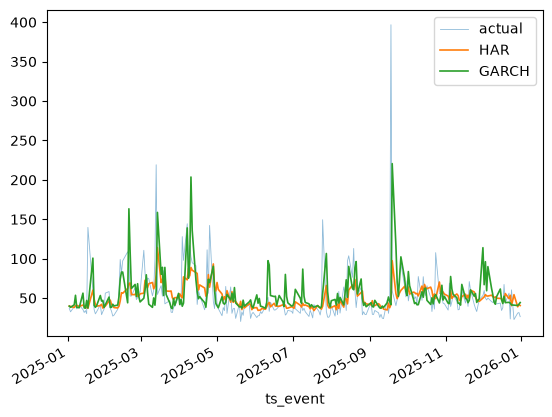

In [7]:
print(forecasts.isna().sum().sum(), (forecasts <= 0).sum().sum())
print(forecasts.describe().loc[["mean", "50%"]])

ax = np.sqrt(p.loc[oos_dates, "V_rv"] * 252).mul(100).plot(lw=0.6, alpha=0.5, label="actual")
np.sqrt(forecasts["har_V_rv"] * 252).mul(100).plot(ax=ax, lw=1.2, label="HAR")
np.sqrt(forecasts["garch"] * 252).mul(100).plot(ax=ax, lw=1.2, label="GARCH")
ax.legend()

In [8]:
forecasts.head()

,naive_V_rv,har_V_rv,naive_V_GK,har_V_GK,naive_V_CC,har_V_CC,garch
ts_event,,,,,,,
2025-01-02 00:00:00-05:00,0.000584,0.000633,0.000404,0.000593,0.000157,0.001440,0.000629
2025-01-03 00:00:00-05:00,0.000545,0.000619,0.000274,0.000526,0.000063,0.001477,0.000581
2025-01-06 00:00:00-05:00,0.000422,0.000576,0.000489,0.000591,0.000278,0.001672,0.000684
2025-01-07 00:00:00-05:00,0.000606,0.000645,0.001008,0.000709,0.001235,0.002083,0.001139
2025-01-08 00:00:00-05:00,0.000666,0.000663,0.000304,0.000543,0.000064,0.001695,0.000582


In [9]:
def qlike(actual, forecast):
    """QLIKE loss function. Both inputs must be positive."""
    return np.log(forecast) + actual / forecast

losses = pd.DataFrame(index=oos_dates)

for proxy in PROXIES:
    actual = p[proxy].loc[oos_dates]
    losses[f"naive_{proxy}"] = qlike(actual, forecasts[f"naive_{proxy}"])
    losses[f"har_{proxy}"] = qlike(actual, forecasts[f"har_{proxy}"])
    losses[f"garch_{proxy}"] = qlike(actual, forecasts["garch"])

print(losses.shape)
losses.mean()
    

(250, 9)


naive_V_rv    -5.264882
har_V_rv      -5.409395
garch_V_rv    -5.332385
naive_V_GK    -4.875465
har_V_GK      -5.312212
garch_V_GK    -5.305086
naive_V_CC    96.674332
har_V_CC      -5.416647
garch_V_CC    -5.348735
dtype: float64

In [10]:
print(losses["naive_V_CC"].nlargest(15))
print((losses["naive_V_CC"] > 0).sum())
print(losses["naive_V_CC"].median())

ts_event
2025-11-13 00:00:00-05:00    6368.492820
2025-03-26 00:00:00-04:00    4636.893087
2025-04-01 00:00:00-04:00    3889.856818
2025-10-22 00:00:00-04:00    3513.399697
2025-01-15 00:00:00-05:00    2517.182153
2025-08-22 00:00:00-04:00    1019.806628
2025-07-23 00:00:00-04:00     473.059973
2025-01-17 00:00:00-05:00     464.295632
2025-01-30 00:00:00-05:00     420.034331
2025-09-18 00:00:00-04:00     196.410795
2025-11-26 00:00:00-05:00     148.524640
2025-10-27 00:00:00-04:00     139.006887
2025-06-24 00:00:00-04:00     134.372589
2025-12-04 00:00:00-05:00     133.513378
2025-06-18 00:00:00-04:00     114.114771
Name: naive_V_CC, dtype: float64
65
-5.286487557527078


In [11]:
def dm_test(loss_a, loss_b, maxlags=5):
    """Mean loss difference (a - b) with Newey-West standard error."""
    d = (loss_a - loss_b).dropna()
    fit = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return fit.params.iloc[0], fit.bse.iloc[0], fit.tvalues.iloc[0]


def loss_table(losses, dates):
    L = losses.loc[dates]
    rows = []
    for proxy in PROXIES:
        row = {"proxy": proxy, "n": len(L)}
        for model in ["naive", "har", "garch"]:
            row[model] = L[f"{model}_{proxy}"].mean()
            row[model + "_med"] = L[f"{model}_{proxy}"].median()
        row["best"] = min(["naive", "har", "garch"], key=lambda m: row[m])
        rows.append(row)
    return pd.DataFrame(rows).set_index("proxy")


def diff_table(losses, dates):
    L = losses.loc[dates]
    rows = []
    for proxy in PROXIES:
        for a, b in [("har", "naive"), ("har", "garch"), ("garch", "naive")]:
            mean, se, t = dm_test(L[f"{a}_{proxy}"], L[f"{b}_{proxy}"])
            rows.append({"proxy": proxy,
                         "pair": f"{a} - {b}",
                         "diff": mean,
                         "nw_se": se,
                         "t": t
                         })
    return pd.DataFrame(rows).set_index(["proxy", "pair"])

In [15]:
all_days = oos_dates
no_earnings = oos_dates[~p.loc[oos_dates, "is_earnings"]]

def show(losses, dates, label):
    L = losses.loc[dates]
    print(f"\n{label}  (n = {len(L)})\n")

    tab = pd.DataFrame({
        m.upper(): [L[f"{m}_{px}"].mean() for px in PROXIES]
        for m in ["naive", "har", "garch"]
    }, index=["Realized variance", "Range (GK)", "Close-to-close"])
    tab["Best"] = tab.idxmin(axis=1)
    print(tab.to_string(float_format=lambda v: f"{v:,.6f}"))

    print("\nPairwise differences (negative = first model better)\n")
    rows = []
    for px, name in zip(PROXIES, tab.index):
        for a, b in [("har", "naive"), ("har", "garch"), ("garch", "naive")]:
            d, se, t = dm_test(L[f"{a}_{px}"], L[f"{b}_{px}"])
            rows.append({"Proxy": name, "Comparison": f"{a.upper()} − {b.upper()}",
                         "Δ loss": f"{d:,.6f}", "NW s.e.": f"{se:,.6f}",
                         "t": f"{t:.6f}", "": "*" if abs(t) > 1.96 else ""})
    print(pd.DataFrame(rows).to_string(index=False))

show(losses, all_days, "PRIMARY — all OOS days")
show(losses, no_earnings, "SENSITIVITY — earnings days excluded")


PRIMARY — all OOS days  (n = 250)

                      NAIVE       HAR     GARCH Best
Realized variance -5.264882 -5.409395 -5.332385  HAR
Range (GK)        -4.875465 -5.312212 -5.305086  HAR
Close-to-close    96.674332 -5.416647 -5.348735  HAR

Pairwise differences (negative = first model better)

            Proxy    Comparison      Δ loss   NW s.e.         t  
Realized variance   HAR − NAIVE   -0.144514  0.044832 -3.223458 *
Realized variance   HAR − GARCH   -0.077010  0.051026 -1.509227  
Realized variance GARCH − NAIVE   -0.067503  0.074814 -0.902280  
       Range (GK)   HAR − NAIVE   -0.436747  0.101835 -4.288755 *
       Range (GK)   HAR − GARCH   -0.007126  0.080828 -0.088157  
       Range (GK) GARCH − NAIVE   -0.429622  0.159834 -2.687924 *
   Close-to-close   HAR − NAIVE -102.090978 39.430562 -2.589133 *
   Close-to-close   HAR − GARCH   -0.067911  0.208523 -0.325678  
   Close-to-close GARCH − NAIVE -102.023067 39.435416 -2.587092 *

SENSITIVITY — earnings days excluded

In [18]:
frozen = forecasts["har_V_rv"]        # one forecast series, never changes

rows = []
for proxy, name in zip(PROXIES, ["Realized variance", "Range (GK)", "Close-to-close"]):
    L = qlike(p.loc[oos_dates, proxy], frozen)
    rows.append({"Evaluation proxy": name,
                 "Mean QLIKE": L.mean(),
                 "Median QLIKE": L.median()})

fixed = pd.DataFrame(rows).set_index("Evaluation proxy")
print(fixed.round(6))

                   Mean QLIKE  Median QLIKE
Evaluation proxy                           
Realized variance   -5.409395     -6.110929
Range (GK)          -5.382443     -6.119517
Close-to-close      -5.451001     -6.397942


In [17]:
print("\nspread across proxies:", round(fixed["Mean QLIKE"].max() - fixed["Mean QLIKE"].min(), 6))
print("har - garch on V_rv (Part 4):", round(losses["har_V_rv"].mean() - losses["garch_V_rv"].mean(), 6))


spread across proxies: 0.068559
har - garch on V_rv (Part 4): -0.07701


In [18]:
for proxy in ["V_GK", "V_CC"]:
    frozen_loss  = qlike(p.loc[oos_dates, proxy], forecasts["har_V_rv"])
    matched_loss = qlike(p.loc[oos_dates, proxy], forecasts[f"har_{proxy}"])
    print(proxy, dm_test(frozen_loss, matched_loss))

V_GK (np.float64(-0.0702308703526047), np.float64(0.0706965599210925), np.float64(-0.9934128397618275))
V_CC (np.float64(-0.03435454174583649), np.float64(0.18358880662765648), np.float64(-0.18712764888500125))


In [19]:
# Same design as the frozen-HAR test, applied to naive. Proxy held fixed, model held fixed, only the input series (forecast)changes.

for proxy in ["V_rv", "V_CC"]:
    a = qlike(p.loc[oos_dates, proxy], forecasts["naive_V_CC"])   # CC as input
    b = qlike(p.loc[oos_dates, proxy], forecasts["naive_V_rv"])   # RV as input
    print(proxy, a.mean(), b.mean(), dm_test(a, b))

V_rv 91.12188781472214 -5.264881688829959 (np.float64(96.38676950355209), np.float64(26.506677226054936), np.float64(3.6363203385148553))
V_CC 96.67433160755544 -5.346050233526226 (np.float64(102.02038184108169), np.float64(39.441164226878534), np.float64(2.5866473224326474))
